In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [62]:
from data_loader import load_all_stations

df = load_all_stations()
df.head()


Loaded 12 station files combined shape (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [63]:
df.shape

(420768, 18)

In [64]:
df["PM2.5"].describe()

count    412029.000000
mean         79.793428
std          80.822391
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         999.000000
Name: PM2.5, dtype: float64

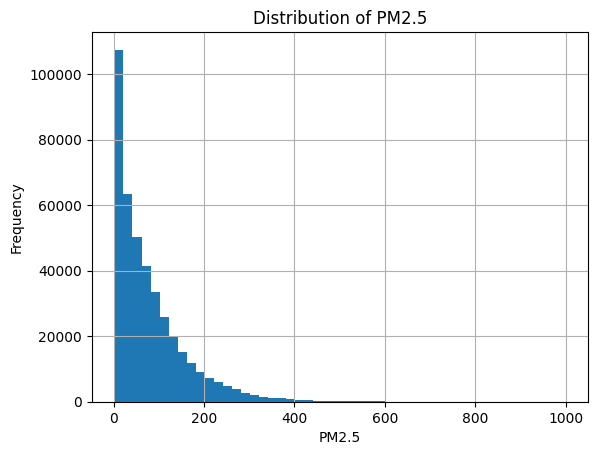

In [65]:
df["PM2.5"].hist(bins=50)
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5")
plt.show()

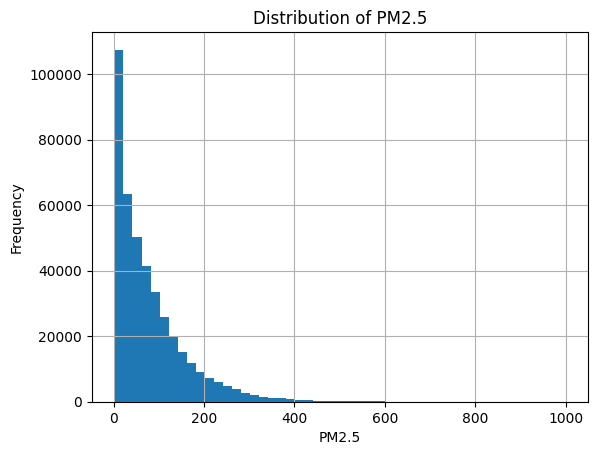

In [66]:
df["PM2.5"].hist(bins=50)

plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5")
plt.show()

In [67]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,420768.0,NaN,NaN,NaN,17532.5,10122.116943,1.0,8766.75,17532.5,26298.25,35064.0
year,420768.0,NaN,NaN,NaN,2014.66256,1.177198,2013.0,2014.0,2015.0,2016.0,2017.0
month,420768.0,NaN,NaN,NaN,6.52293,3.448707,1.0,4.0,7.0,10.0,12.0
day,420768.0,NaN,NaN,NaN,15.729637,8.800102,1.0,8.0,16.0,23.0,31.0
hour,420768.0,NaN,NaN,NaN,11.5,6.922195,0.0,5.75,11.5,17.25,23.0
PM2.5,412029.0,NaN,NaN,NaN,79.793428,80.822391,2.0,20.0,55.0,111.0,999.0
PM10,414319.0,NaN,NaN,NaN,104.602618,91.772426,2.0,36.0,82.0,145.0,999.0
SO2,411747.0,NaN,NaN,NaN,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,NaN,NaN,NaN,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,NaN,NaN,NaN,1230.766454,1160.182716,100.0,500.0,900.0,1500.0,10000.0


In [68]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [69]:
pollutant_cols = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]
meteorological_cols = [
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
    "wd"
]


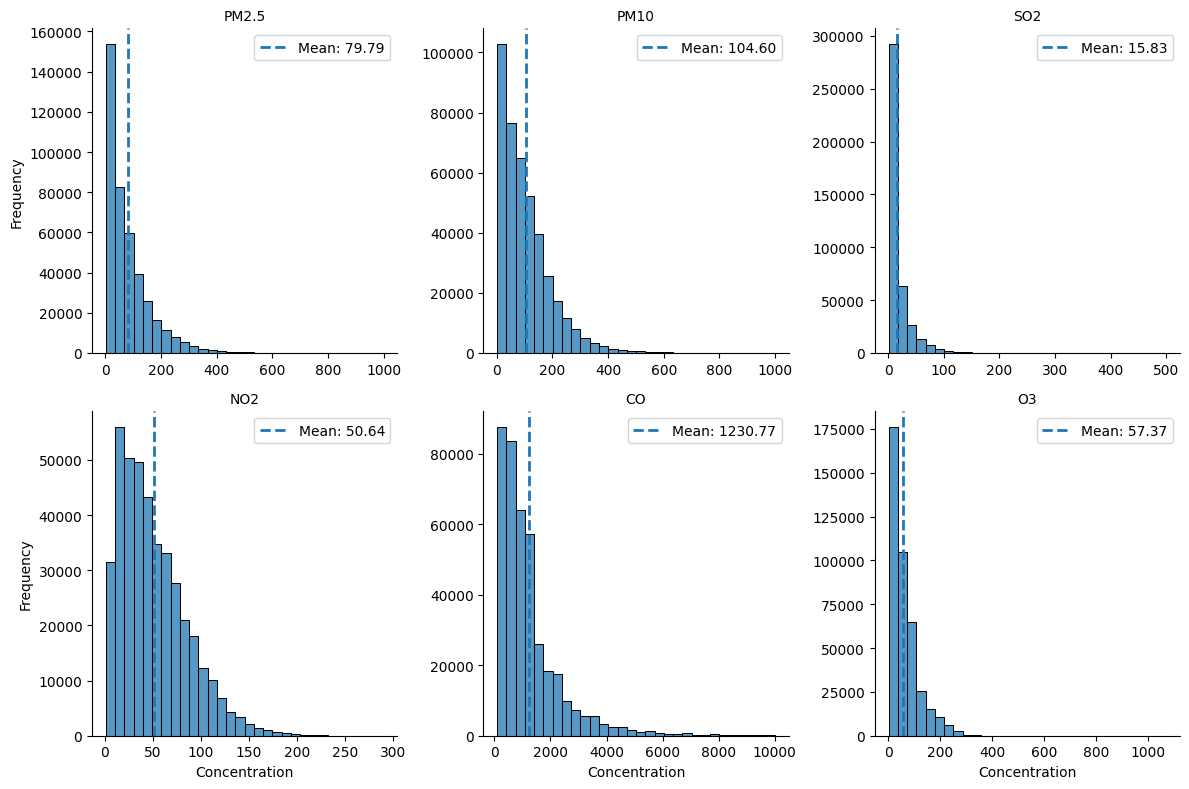

In [70]:

pollutant_df = df[pollutant_cols].melt(
    var_name="Pollutant",
    value_name="Concentration"
)

g = sns.FacetGrid(
    pollutant_df,
    col="Pollutant",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x="Concentration",
    bins=30
)

for ax, pollutant in zip(g.axes.flat, pollutant_cols):
    mean_value = df[pollutant].mean()

    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )

    ax.legend()

g.set_axis_labels("Concentration", "Frequency")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

In [71]:
for feature in meteorological_cols:
    print(feature, df[feature].dtype)
    try:
        print(df[feature].mean())
    except Exception as e:
        print(e)

TEMP float64
13.53897583381636
PRES float64
1010.7469819844987
DEWP float64
2.490822023717484
RAIN float64
0.06447578132062097
WSPM float64
1.729710548222143
wd object
can only concatenate str (not "int") to str


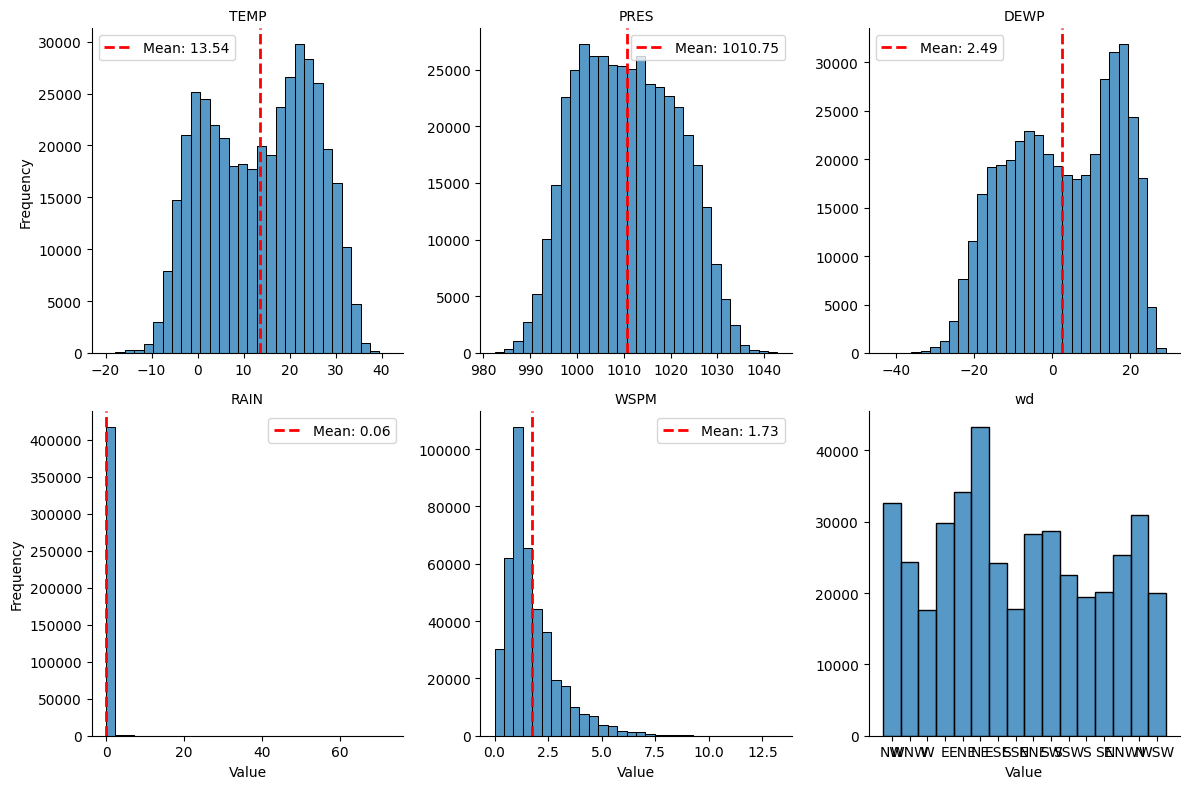

In [72]:
meteorological_df = df[meteorological_cols].melt(
    var_name="Feature",
    value_name="Value"
)

g = sns.FacetGrid(
    meteorological_df,
    col="Feature",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x="Value",
    bins=30
)

for ax, feature in zip(g.axes.flat, meteorological_cols):
    if pd.api.types.is_numeric_dtype(df[feature]):
        mean_value = df[feature].mean()

        ax.axvline(
            mean_value,
            linestyle="--",
            linewidth=2,
            color="red",
            label=f"Mean: {mean_value:.2f}"
        )
        ax.legend()
g.set_axis_labels("Value", "Frequency")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

In [73]:
df[["WSPM", "PM2.5"]].corr()

,WSPM,PM2.5
WSPM,1.000000,-0.272205
PM2.5,-0.272205,1.000000


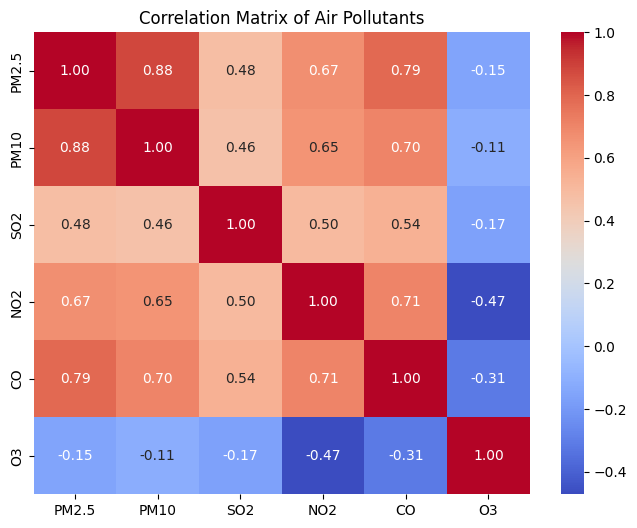

In [74]:
pollutant_cols = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

corr_matrix = df[pollutant_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Air Pollutants")
plt.show()

In [75]:
corr_matrix

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.000000,0.884380,0.482354,0.666948,0.789998,-0.149697
PM10,0.884380,1.000000,0.462651,0.652193,0.702363,-0.111294
SO2,0.482354,0.462651,1.000000,0.499496,0.535750,-0.165341
NO2,0.666948,0.652193,0.499496,1.000000,0.705500,-0.471587
CO,0.789998,0.702363,0.535750,0.705500,1.000000,-0.313012
O3,-0.149697,-0.111294,-0.165341,-0.471587,-0.313012,1.000000


In [76]:
df["year"].value_counts().sort_index()

year
2013     88128
2014    105120
2015    105120
2016    105408
2017     16992
Name: count, dtype: int64

In [77]:
print(df.isnull().sum())
print(df.shape)


No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64
(420768, 18)


In [78]:
print(df.isnull().any(axis=1).sum())  # total rows affected
print(df.groupby('station').apply(lambda g: g.isnull().sum()))

38600
               No  year  month  day  hour  PM2.5  PM10   SO2   NO2    CO  \
station                                                                    
Aotizhongxin    0     0      0    0     0    925   718   935  1023  1776   
Changping       0     0      0    0     0    774   582   628   667  1521   
Dingling        0     0      0    0     0    779   656   730  1234  2012   
Dongsi          0     0      0    0     0    750   553   663  1601  3197   
Guanyuan        0     0      0    0     0    616   429   474   659  1753   
Gucheng         0     0      0    0     0    646   381   507   668  1401   
Huairou         0     0      0    0     0    953   777   980  1639  1422   
Nongzhanguan    0     0      0    0     0    628   440   446   692  1206   
Shunyi          0     0      0    0     0    913   548  1296  1365  2178   
Tiantan         0     0      0    0     0    677   597  1118   744  1126   
Wanliu          0     0      0    0     0    382   284   575  1070  1812   
Wansho

/var/folders/qg/fq9xw4y90wb1czds20rzth_c0000gn/T/ipykernel_55457/2131699774.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('station').apply(lambda g: g.isnull().sum()))


In [79]:
df.to_csv("data.csv", index=False)

In [80]:
def longest_gap(s):
    is_na = s.isna()
    return (is_na * (is_na.groupby((~is_na).cumsum()).cumcount() + 1)).max()

print(df.groupby('station')['CO'].apply(longest_gap))

station
Aotizhongxin      344
Changping         176
Dingling         1052
Dongsi           1518
Guanyuan          442
Gucheng           350
Huairou           212
Nongzhanguan      148
Shunyi            750
Tiantan            94
Wanliu            643
Wanshouxigong      94
Name: CO, dtype: int64


In [81]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [82]:
df['CO'].corr(df['PM2.5'])

0.7899978240028822

In [83]:
regional_co = df.groupby(['year','month','day','hour'])['CO'].transform('mean')

# fill missing CO with regional average where available
df['CO'] = df['CO'].fillna(regional_co)

In [84]:
fully_missing_hours = df.groupby(['year','month','day','hour'])['CO'].apply(lambda x: x.isna().all())
print(fully_missing_hours.sum())

204


In [85]:
df['wd'].unique()

array(['NW', 'WNW', 'W', 'E', 'ENE', 'NE', 'ESE', 'SSE', 'NNE', 'SW',
       'SSW', 'S', 'SE', 'NNW', 'N', 'WSW', nan], dtype=object)